# Simulation Playground Notebook
This notebook is designed as a easy einterface to call the functions that we have defined

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

import torch.optim as optim
import torch.nn as nn
import torch

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_participants_info, load_event_descriptions, load_behavioral_data, preprocess_data, preprocess_data_stress, preprocess_data_duration

# Data Preparation
Let's prepare some data first to fit our model. We are specifically using ["Locus coeruleus activity strengthens prioritized memories under arousal"](https://openneuro.org/datasets/ds002011/versions/1.0.0) dataset fror now.

In [2]:
DATASET_PATH = "data"
participants_df = load_participants_info(DATASET_PATH)
load_event_descriptions(DATASET_PATH)

df_behavior = load_behavioral_data(DATASET_PATH, "01")
for idx in range(2,11):
    sample_participant = f"0{idx}"
    df = load_behavioral_data(DATASET_PATH, sample_participant)
    df_behavior = pd.concat([df, df_behavior], ignore_index=True)

Let's preprocess our data first

In [3]:
X, Y, X_tensor, Y_tensor, scaler_X, scaler_Y, df_clean = preprocess_data(df_behavior)
X_stress = preprocess_data_stress(df_behavior, condition="AROUSING")
X_neurtal = preprocess_data_stress(df_behavior, condition="NEUTRAL")
X_long = preprocess_data_duration(df_behavior, duration="long")
X_short = preprocess_data_duration(df_behavior, duration="short")

X Shape: torch.Size([1699, 7]), Y Shape: torch.Size([1699])
Y Min: -1.0, Y Max: 1.0


In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X_tensor, Y_tensor, test_size=0.2, random_state=42)

X_stress_train, X_stress_test = train_test_split(X_stress, test_size=0.2, random_state=42)
X_neutral_train, X_neutral_test = train_test_split(X_neurtal, test_size=0.2, random_state=42)
X_long_train, X_long_test = train_test_split(X_long, test_size=0.2, random_state=42)
X_short_train, X_short_test = train_test_split(X_short, test_size=0.2, random_state=42)

# Training

In [5]:
from train import (train_feed_forward_nn,
                   train_vanilla_lstm,
                   train_vanilla_lc_model,
                   train_lstm_lc_model,
                   train_ff_controller,
                   train_ff_uncertain_controller
                   )
from analysis.evaluation import evaluate_model

## Fully Connected Neural Network

To illustrate our idea, we want to train 2 models from math and computer science, which is our vanilla feed forward networks and an recurrent networks.

Epoch 0, Loss: 0.0734705999493599
Epoch 100, Loss: 0.04654915630817413
Epoch 200, Loss: 0.044795725494623184
Epoch 300, Loss: 0.04361651837825775
Epoch 400, Loss: 0.04276026785373688
Epoch 500, Loss: 0.04238421842455864
Epoch 600, Loss: 0.04187016189098358
Epoch 700, Loss: 0.041696466505527496
Epoch 800, Loss: 0.04361952096223831
Epoch 900, Loss: 0.04119894281029701
Epoch 1000, Loss: 0.03984207287430763
Epoch 1100, Loss: 0.03983554616570473
Epoch 1200, Loss: 0.03919224441051483
Epoch 1300, Loss: 0.03929945454001427
Epoch 1400, Loss: 0.039488065987825394
Epoch 1500, Loss: 0.03884779289364815
Epoch 1600, Loss: 0.03859015554189682
Epoch 1700, Loss: 0.03874100372195244
Epoch 1800, Loss: 0.0379965603351593
Epoch 1900, Loss: 0.038456663489341736
Training complete!
Evaluating Model: FeedForwardNN


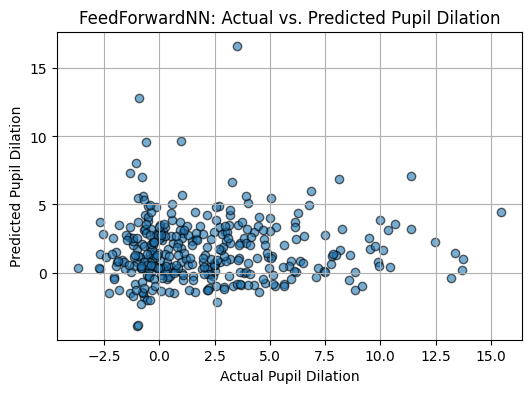

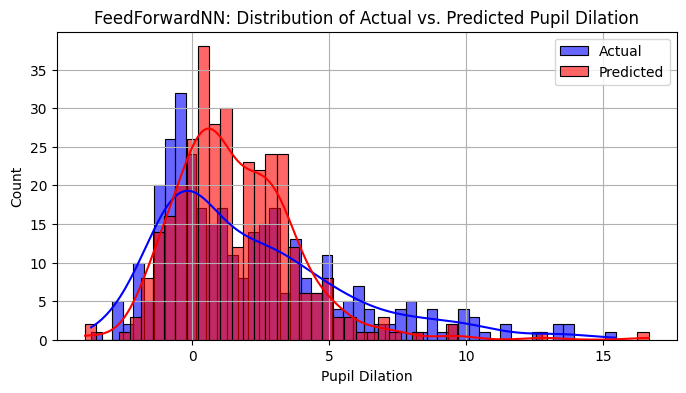

FeedForwardNN - Pearson Correlation: 0.0438


In [6]:
model_ff = train_feed_forward_nn(X_train, Y_train,epochs=2000)
evaluate_model(model_ff, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## Recurent Neural Networks

We will  do the same thing with an recurrent neural network

In [7]:
# model_rnn = train_vanilla_rnn(X_train, Y_train, epochs=2000)
# evaluate_model(model_rnn, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LSTM Models

In [8]:
# model_lstm = train_vanilla_lstm(X_train, Y_train, epochs=5000, hidden_dim=12)
# evaluate_model(model_lstm, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LCNECortex Fitter Model

Now coming to our customized LCNECortex model

In [9]:
# model_lc_vanilla = train_vanilla_lc_model(X_train, Y_train, epochs=2000)
# evaluate_model(model_lc_vanilla, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LSTM LCNECortex Model

In [10]:
# model_lc_lstm = train_lstm_lc_model(X_train, Y_train, epochs=2000, hidden_dim=64)
# evaluate_model(model_lc_lstm, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

# FF Gadget Model

Epoch 0, Loss: 0.028397


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.020059
Epoch 200, Loss: 0.024376
Early stopping triggered at epoch 292
Training complete!
Evaluating Model: FFGadgetController


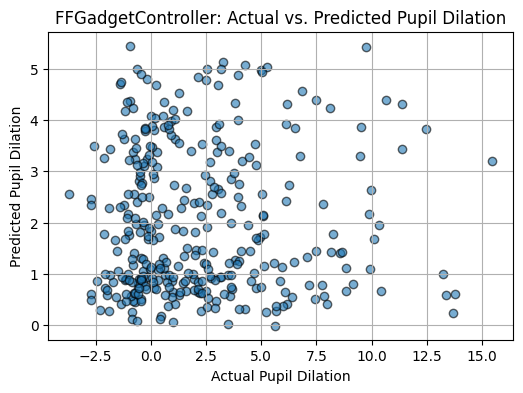

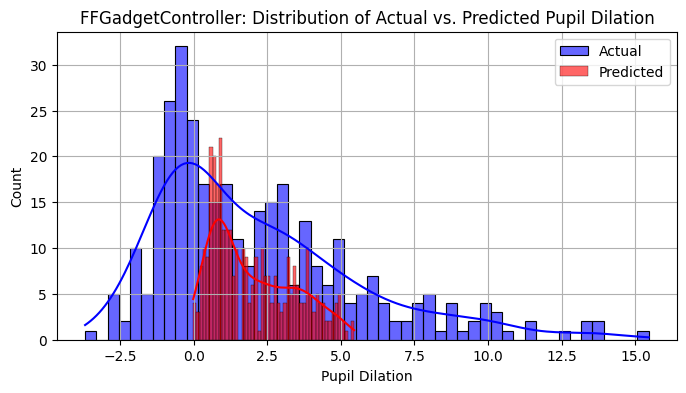

FFGadgetController - Pearson Correlation: 0.0277


In [11]:
ff_gadget = train_ff_controller(X_train, Y_train, epochs=5000, hidden_dim=124, patience=200)
evaluate_model(ff_gadget, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## Modified Uncertainty GadgetModel

Epoch 0, Loss: 0.608241


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.045685
Epoch 200, Loss: 0.049063
Epoch 300, Loss: 0.041365
Epoch 400, Loss: 0.045438
Early stopping triggered at epoch 435
Training complete!


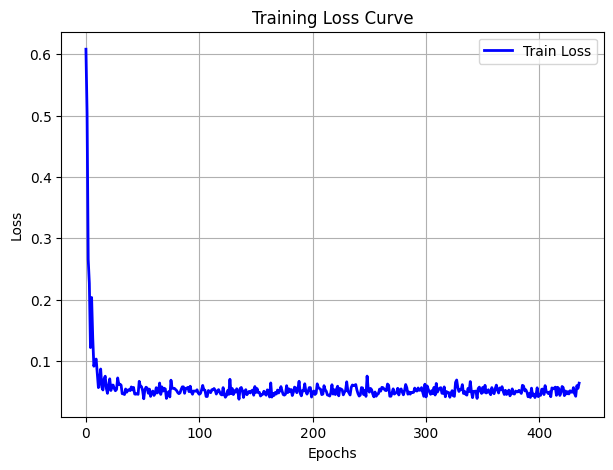

Evaluating Model: FFGadgetUncertainController
Adjusting prev_LC size: torch.Size([256, 256]) -> torch.Size([340, 256])


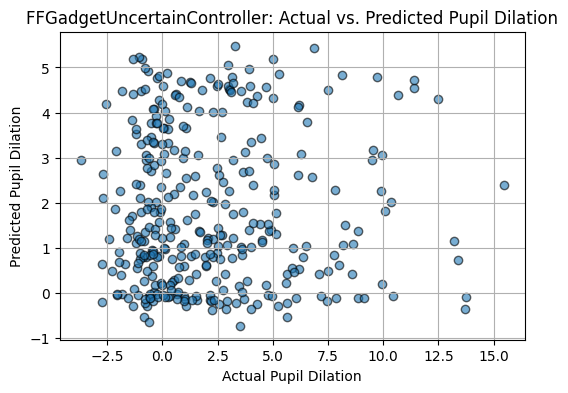

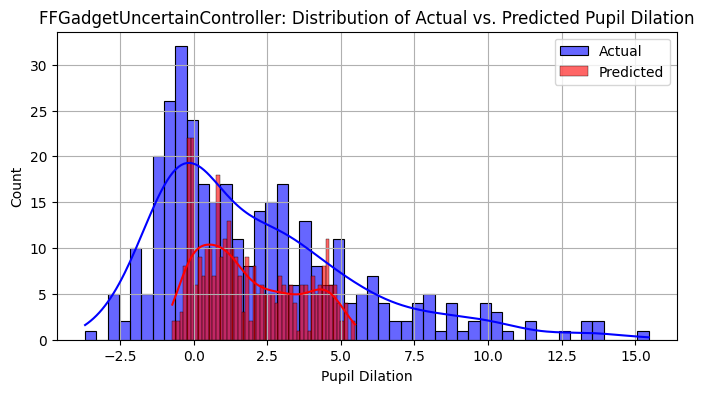

FFGadgetUncertainController - Pearson Correlation: 0.0146


In [12]:
# ff_uncertain_gadget = train_ff_uncertain_controller(X_tensor, Y_tensor, epochs=1000, hidden_dim=256, batch_size=256, patience=300)
ff_uncertain_gadget = train_ff_uncertain_controller(X_tensor, Y_tensor, epochs=1000, hidden_dim=256, batch_size=256, patience=300, entropy_scale=0.5)
evaluate_model(ff_uncertain_gadget, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

# Analysis

In [13]:
from analysis.analysis import (pca_lcne_lstm,
                               pca_feed_forward,
                               pca_lcne,
                               pca_lstm,
                               analyze_ff_gadget_activations,
                               evaluate_ff_uncertainty_gadget
)

/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Feed-Forward Neural Networks

In [14]:
# pca_feed_forward(model_ff, X_tensor, df_behavior)

## LCNECortex Model

We will see that, though  under fitted with the real data, there are some structureness to the data that we can play around with since we injected mechanistic insights into it.

In [15]:
# with torch.no_grad():
#     prev_LC = torch.zeros(X_tensor.shape[0], model_lc_vanilla.hidden_dim)
#     prev_Cortex = torch.zeros(X_tensor.shape[0], model_lc_vanilla.hidden_dim)

#     LC_act, NE_act, C_act, Pupil_pred, LC_raw, NE_raw, C_raw = model_lc_vanilla(X_tensor, prev_LC, prev_Cortex, return_activations=True)

# act_lc = LC_act.cpu().numpy()
# act_ne = NE_act.cpu().numpy()
# act_cortex = C_act.cpu().numpy()

# df_activations = pd.DataFrame({
#     'LC_Mean': act_lc.mean(axis=1),
#     'NE_Mean': act_ne.mean(axis=1),
#     'Cortex_Mean': act_cortex.mean(axis=1),
#     'PupilPred': Pupil_pred.cpu().numpy().squeeze(),
#     'ActualPupil': df_clean['Event_PupilDilation'].values  # Ensure this aligns with X_tensor
# })

# plt.figure(figsize=(12, 4))

# plt.subplot(1, 3, 1)
# sns.histplot(df_activations['LC_Mean'], kde=True, bins=50, color='blue')
# plt.title("LC Activation Distribution")

# plt.subplot(1, 3, 2)
# sns.histplot(df_activations['NE_Mean'], kde=True, bins=50, color='green')
# plt.title("NE Activation Distribution")

# plt.subplot(1, 3, 3)
# sns.histplot(df_activations['Cortex_Mean'], kde=True, bins=50, color='red')
# plt.title("Cortex Activation Distribution")

In [16]:
# pca_lcne(model_lc_vanilla, X_tensor, df_clean)

## LSTM LCNECortex Model

In [17]:
# pca_lcne_lstm(model_lc_lstm, X_tensor, df_clean)

## Vanilla LSTM Comparison

In [18]:
# pca_lstm(model_lstm, X_test, df_clean)

## FF Gadget Model

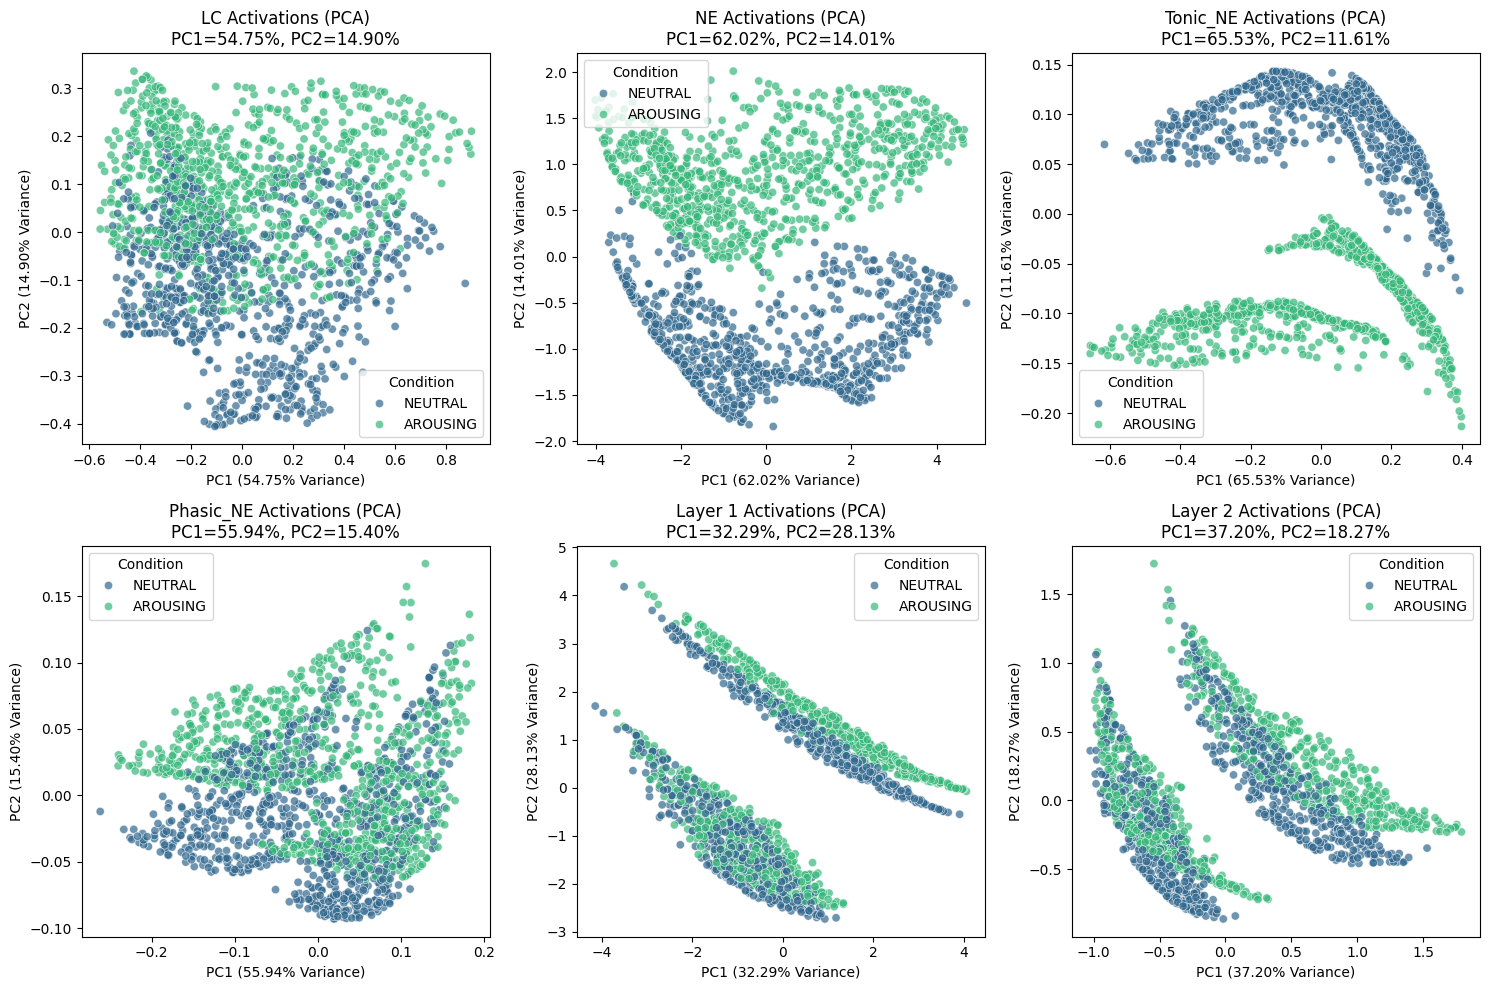

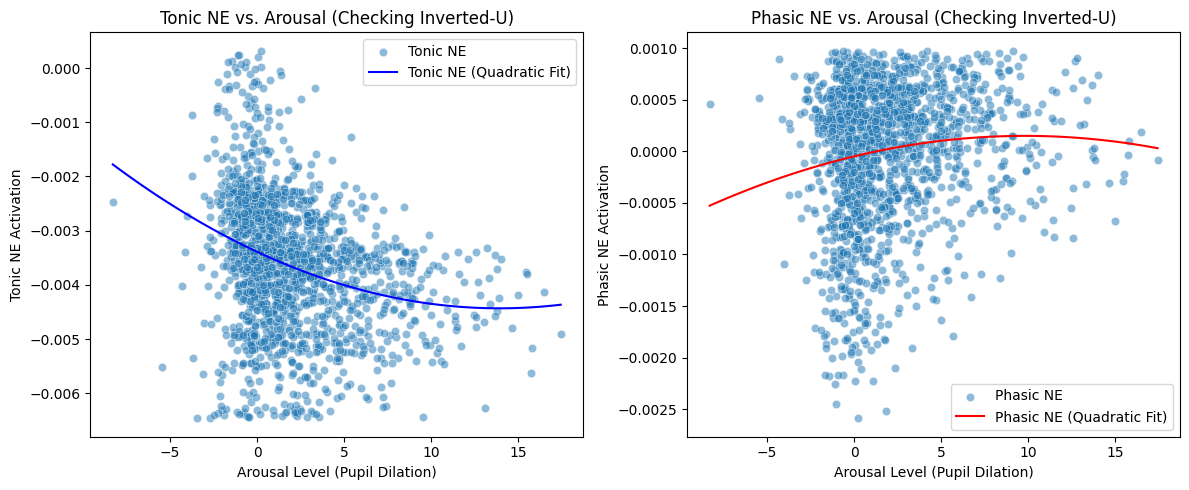


 Pearson Correlation with Actual Pupil Dilation:
LC: -0.210
NE: 0.402
Tonic_NE: -0.280
Phasic_NE: 0.115
Layer 1: 0.196
Layer 2: 0.343
Predicted Pupil Dilation: 0.438


In [19]:
analyze_ff_gadget_activations(ff_gadget, X_tensor, df_clean)

This model elarning representation is quite unstable

## Modified Uncertainty GadgetModel

Adjusting prev_LC size: torch.Size([340, 256]) -> torch.Size([1699, 256])
Pupil Dilation MAE: 2.1691
Pupil Dilation MSE: 8.3627


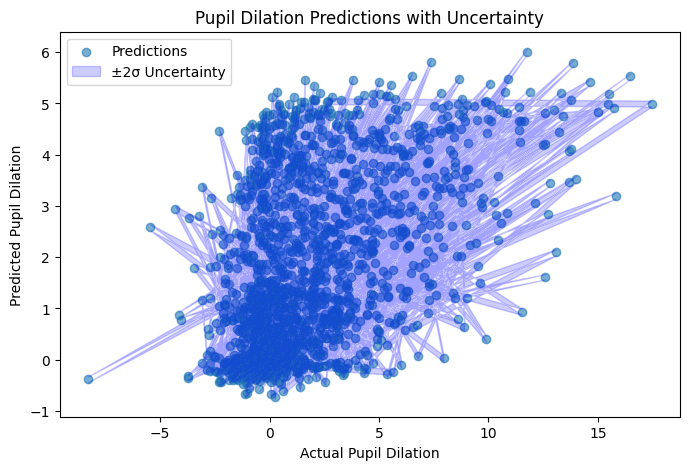

In [20]:
evaluate_ff_uncertainty_gadget(ff_uncertain_gadget, X_tensor, Y_tensor, scaler_Y)

In [21]:
from analysis.analysis import (extract_activations_gadget,
                               compute_mapper_graph,
                               compute_persistent_homology,
                               compute_persistent_homology_overlay,
                               compute_mapper_graph_overlay,
                               plot_manifold_projection,
                               construct_activation_graph,
                               plot_activation_graph)

## Maniforlds Projections

Adjusting prev_LC size: torch.Size([1699, 256]) -> torch.Size([170, 256])
Adjusting prev_LC size: torch.Size([170, 256]) -> torch.Size([171, 256])


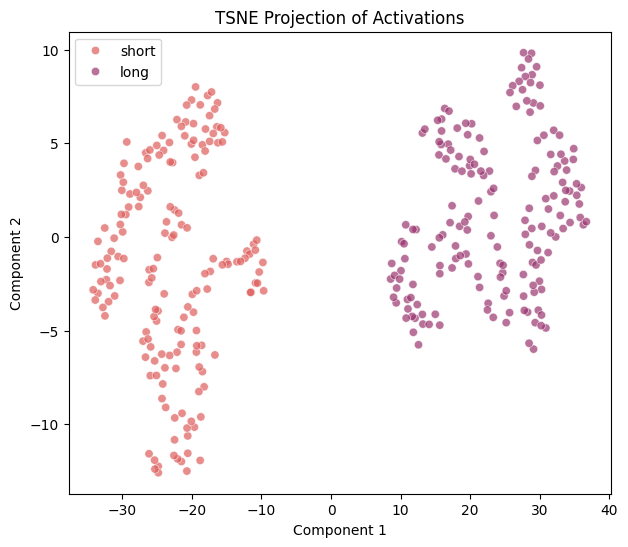

/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


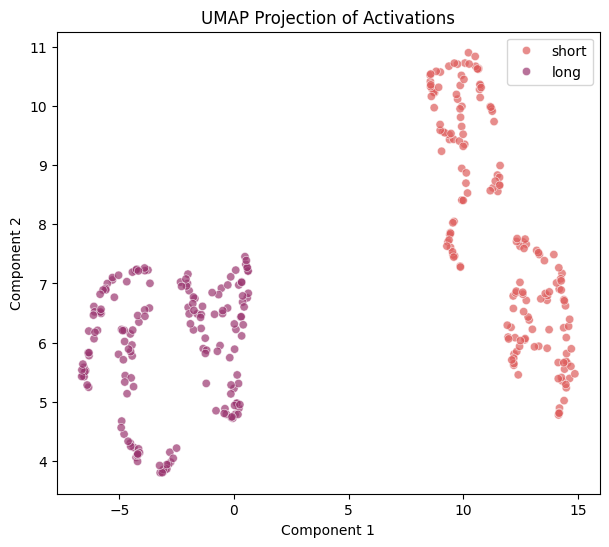

In [22]:
activations_short = extract_activations_gadget(ff_uncertain_gadget, X_short_test)
activations_long = extract_activations_gadget(ff_uncertain_gadget, X_long_test)

all_activations = np.vstack([activations_short["LC"], activations_long["LC"]])
labels = np.array(["short"] * len(activations_short["LC"]) + ["long"] * len(activations_long["LC"]))

# t-SNE projection
plot_manifold_projection(all_activations, labels, method="tsne")

# UMAP projection
plot_manifold_projection(all_activations, labels, method="umap")

## Cosine Similarity Graph

Adjusting prev_LC size: torch.Size([171, 256]) -> torch.Size([851, 256])
Adjusting prev_LC size: torch.Size([851, 256]) -> torch.Size([848, 256])


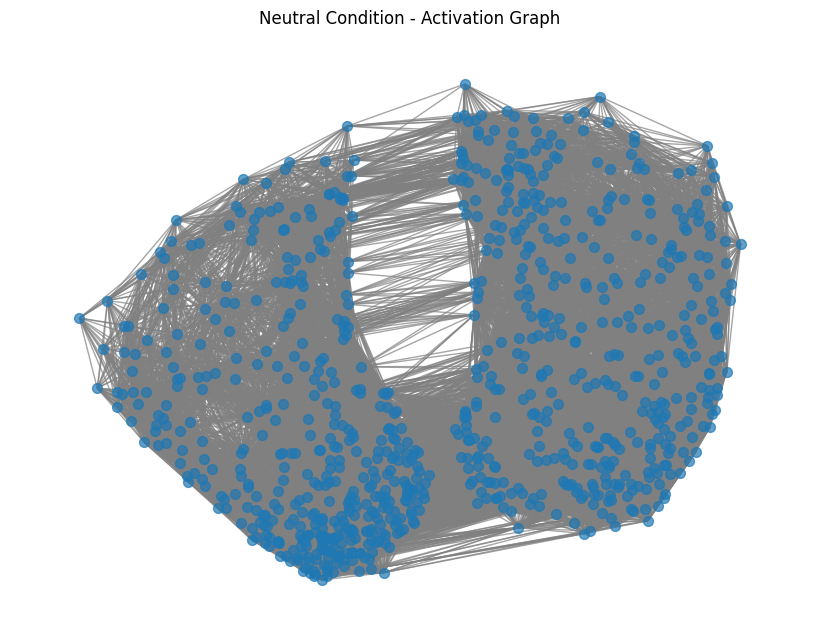

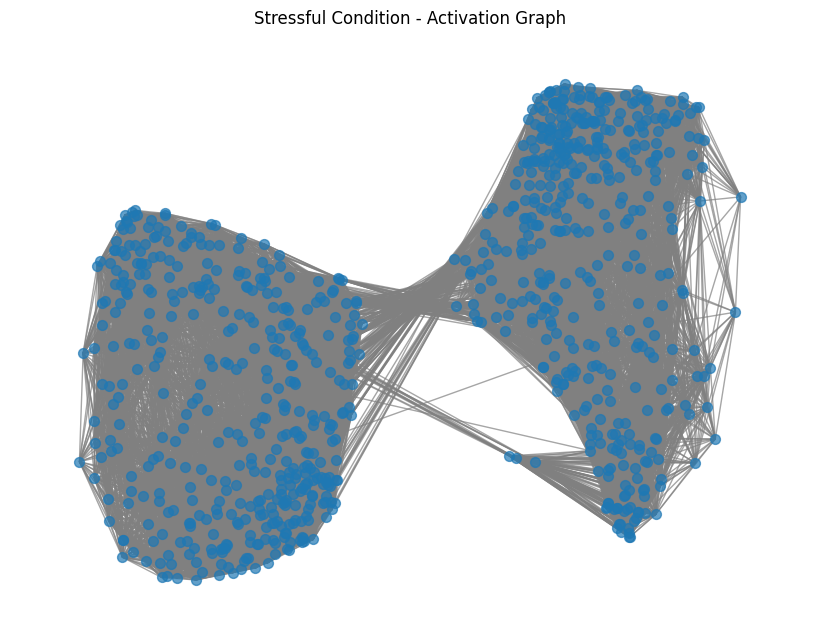

In [23]:
activations_short = extract_activations_gadget(ff_uncertain_gadget, X_long)
activations_long = extract_activations_gadget(ff_uncertain_gadget, X_short)

G_short = construct_activation_graph(activations_short["LC"], threshold=0.991)
G_long = construct_activation_graph(activations_long["LC"], threshold=0.991)

plot_activation_graph(G_short, title="Neutral Condition - Activation Graph")
plot_activation_graph(G_long, title="Stressful Condition - Activation Graph")

## Homology Analyiss

Persistent homology seems to work with the `uncertainty` model but not other models.

Adjusting prev_LC size: torch.Size([848, 256]) -> torch.Size([1699, 256])
Analyzing LC activations...


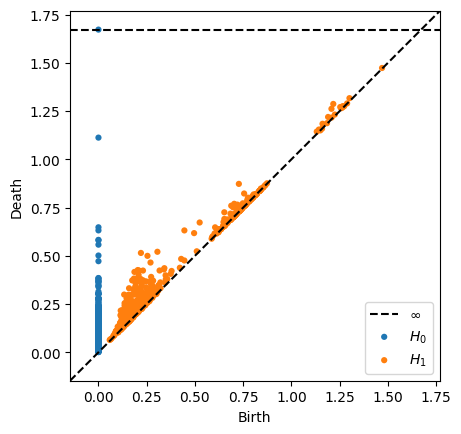

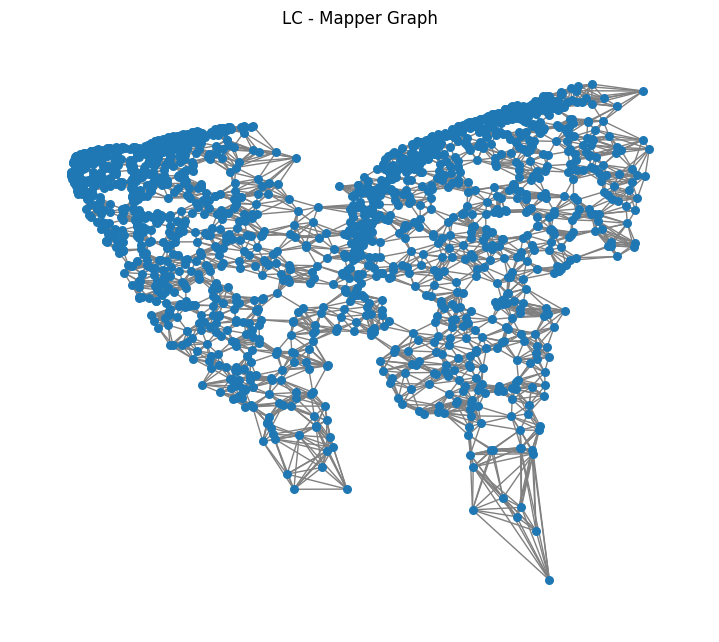

Analyzing NE activations...


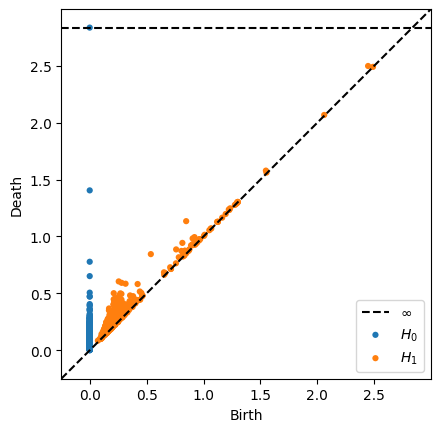

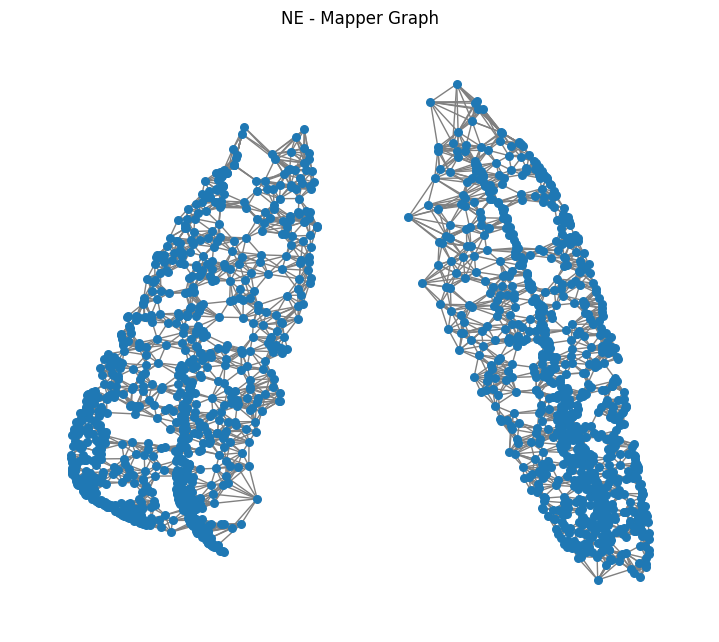

Analyzing Tonic_NE activations...


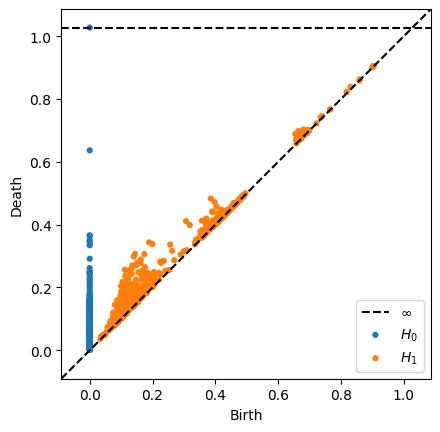

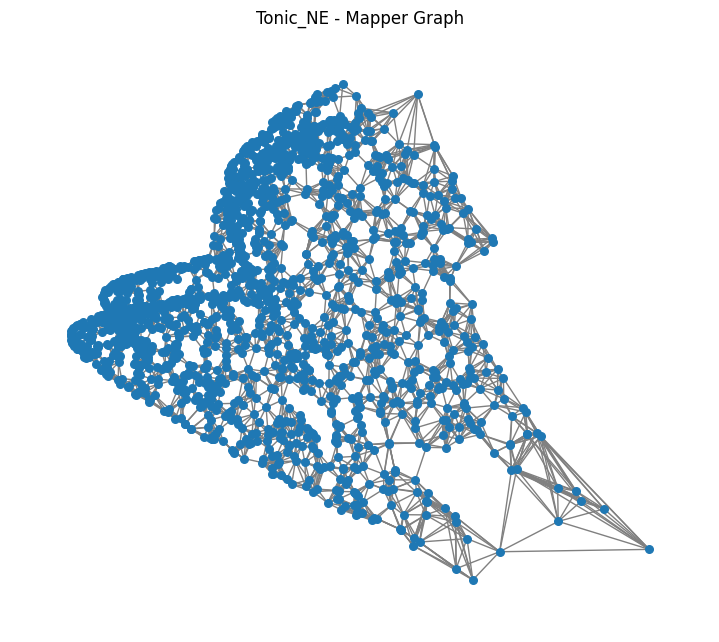

Analyzing Phasic_NE activations...


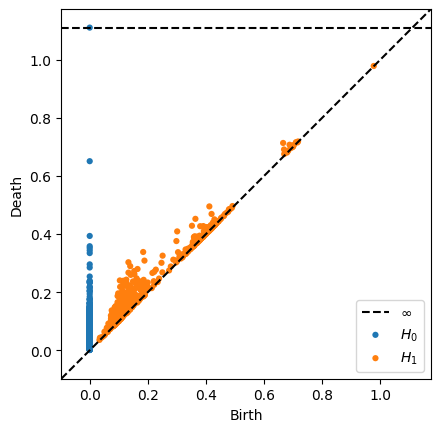

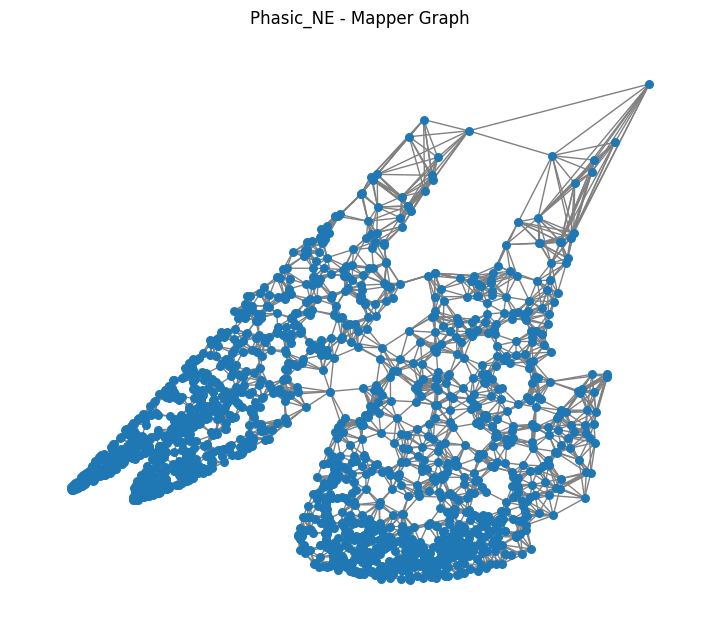

Analyzing Hidden_1 activations...


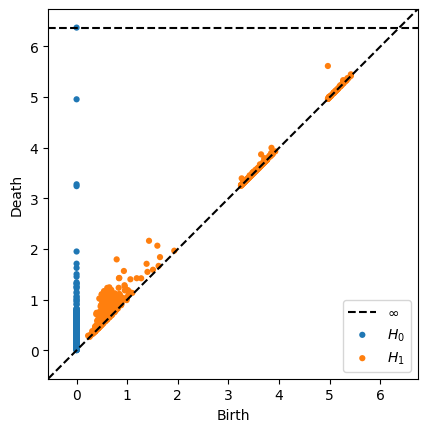

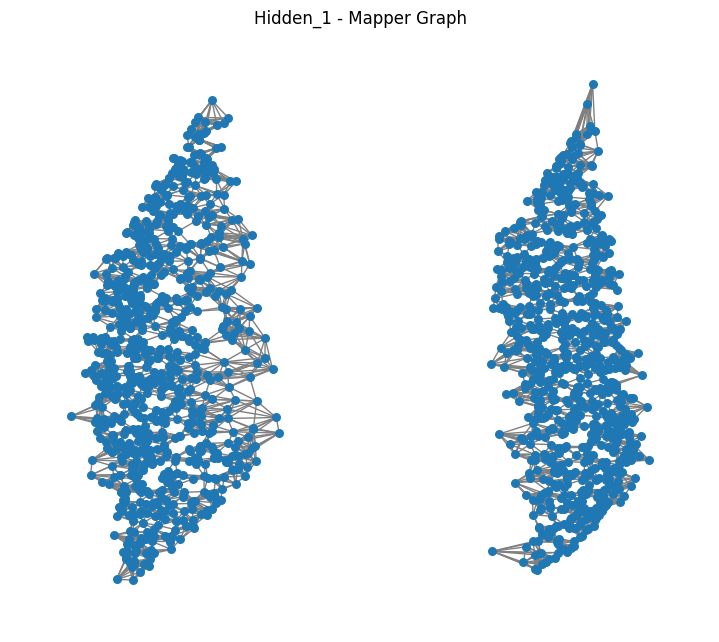

Analyzing Hidden_2 activations...


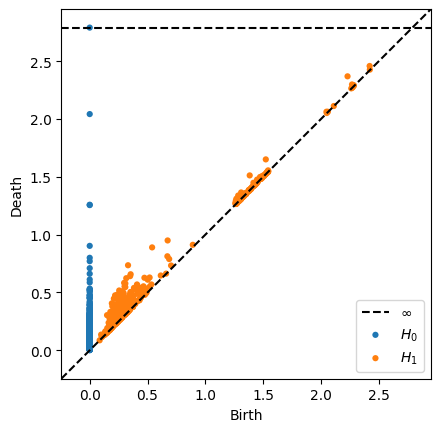

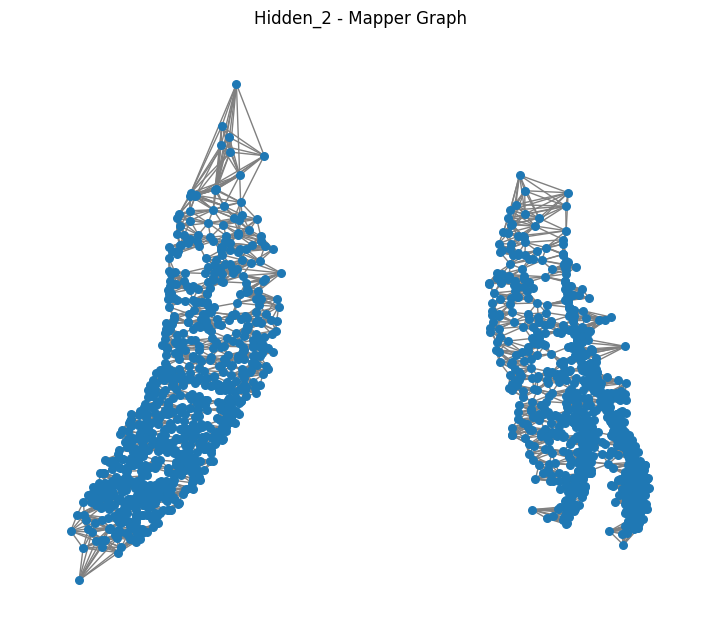

In [24]:
activations = extract_activations_gadget(ff_uncertain_gadget, X_tensor)
# activations = extract_activations_ff_uncertain_gadget(ff_gadget, X_tensor)

for key, act in activations.items():
    print(f"Analyzing {key} activations...")
    compute_persistent_homology(act, title=f"{key} - Persistent Homology")
    compute_mapper_graph(act, title=f"{key} - Mapper Graph")

Adjusting prev_LC size: torch.Size([1699, 256]) -> torch.Size([171, 256])
Adjusting prev_LC size: torch.Size([171, 256]) -> torch.Size([170, 256])
Analyzing LC activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


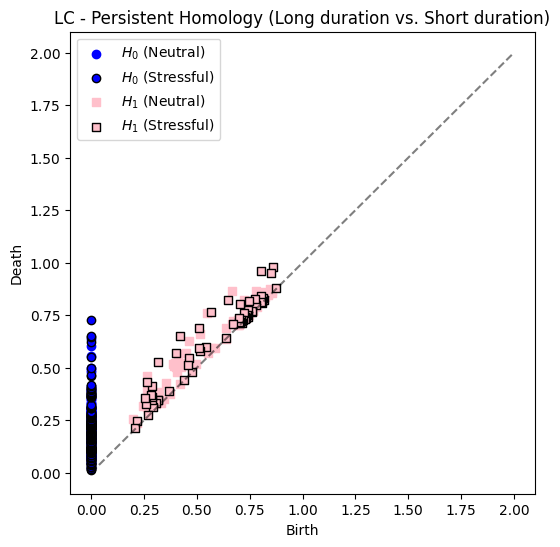

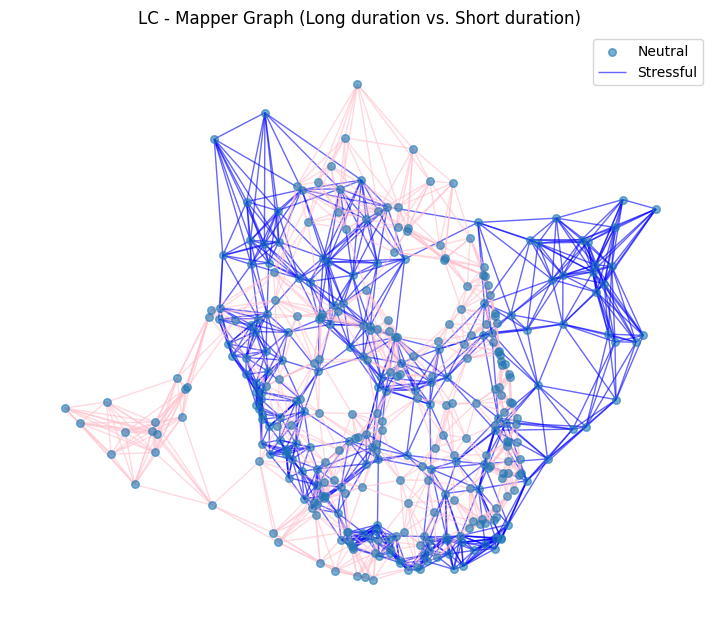

Analyzing NE activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


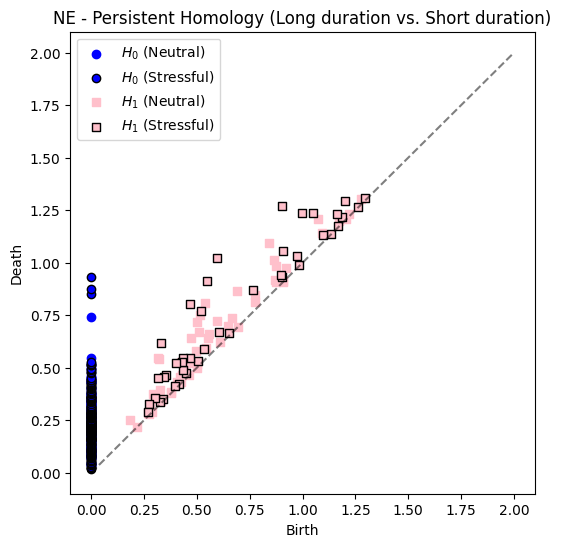

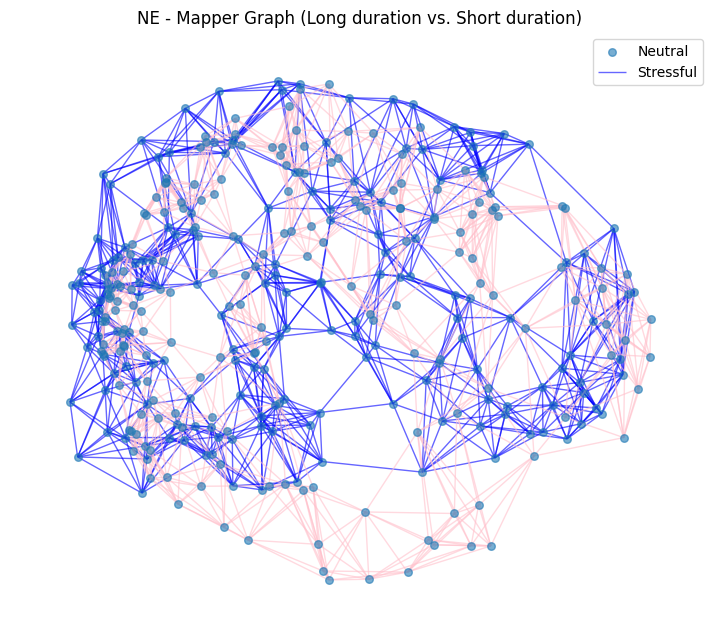

Analyzing Tonic_NE activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


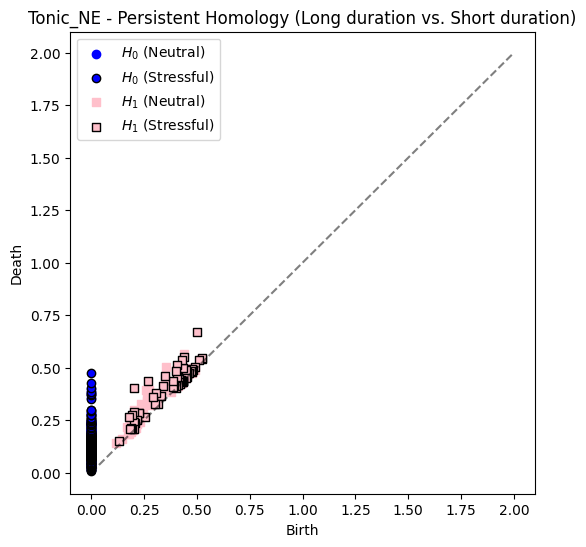

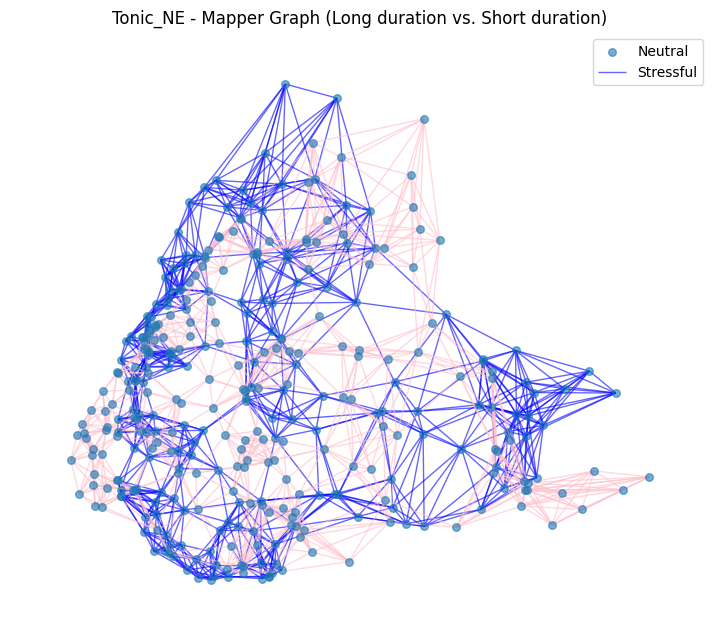

Analyzing Phasic_NE activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


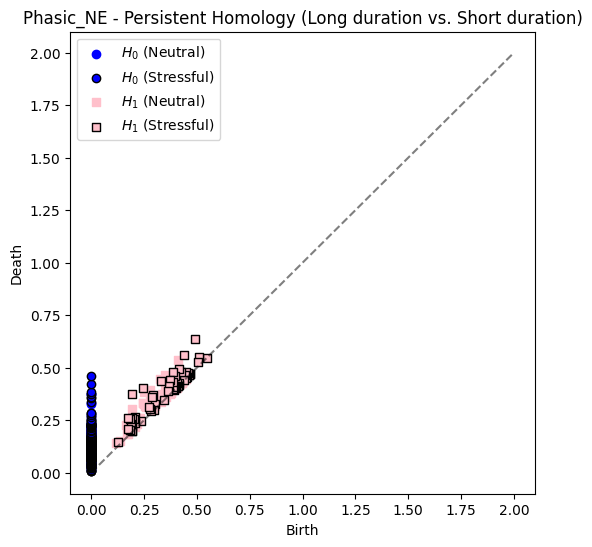

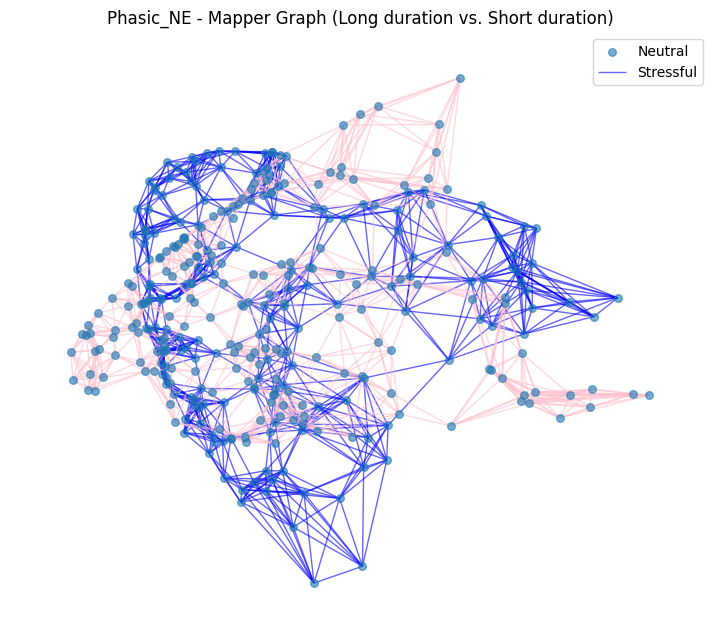

Analyzing Hidden_1 activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


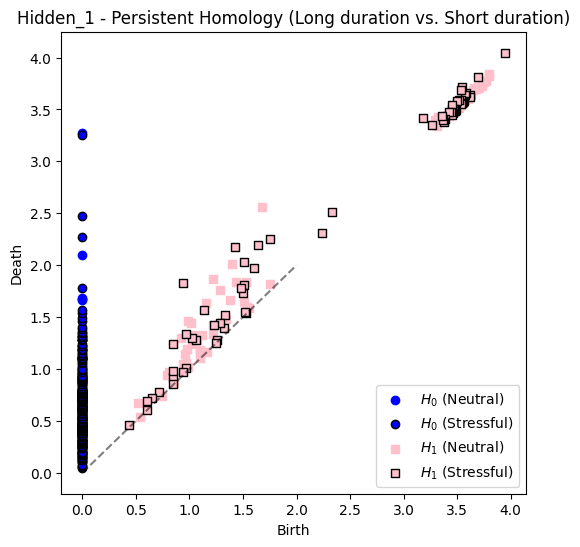

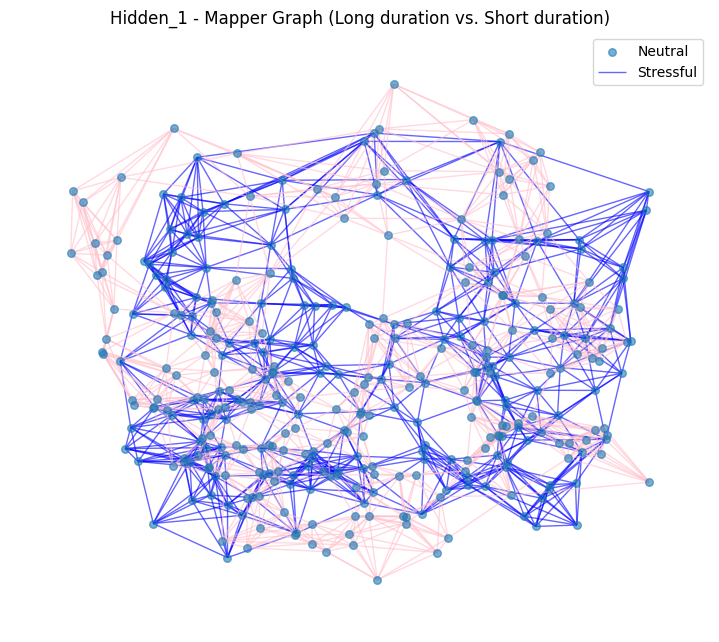

Analyzing Hidden_2 activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


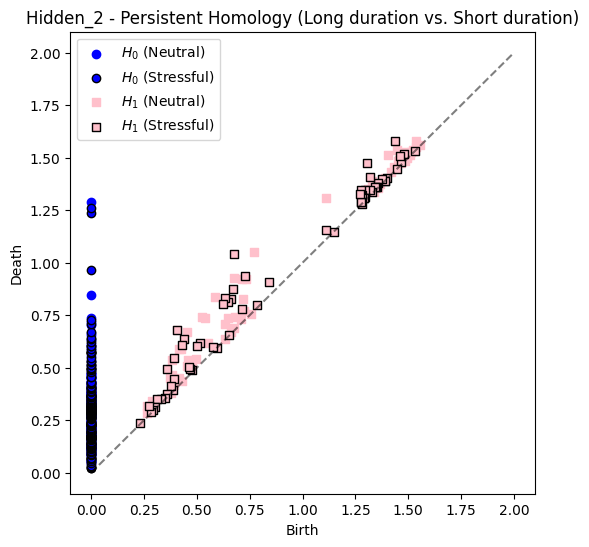

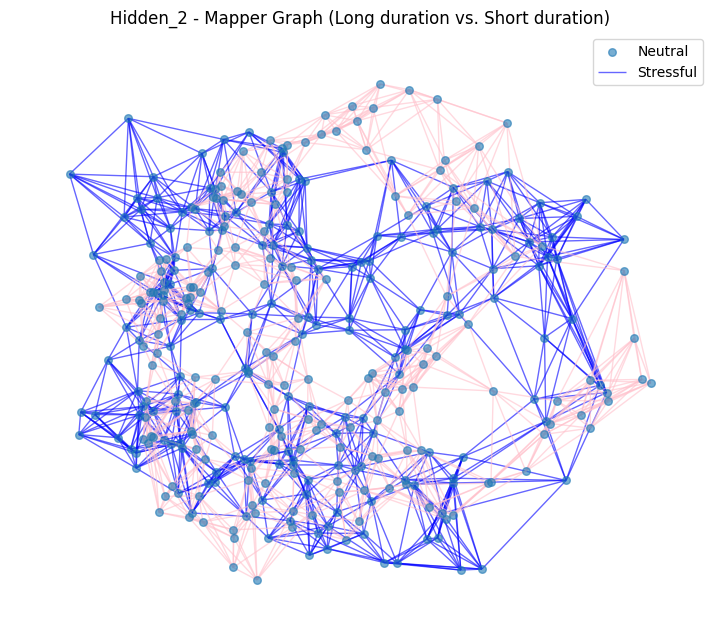

In [25]:
activations_long = extract_activations_gadget(ff_uncertain_gadget, X_long_test)
activations_short = extract_activations_gadget(ff_uncertain_gadget, X_short_test)

for key in activations_long.keys():
    print(f"Analyzing {key} activations...")

    act_long = activations_long[key]
    act_short = activations_short[key]

    compute_persistent_homology_overlay(act_long, act_short, title=f"{key} - Persistent Homology (Long duration vs. Short duration)")

    compute_mapper_graph_overlay(act_long, act_short, title=f"{key} - Mapper Graph (Long duration vs. Short duration)")

Adjusting prev_LC size: torch.Size([170, 256]) -> torch.Size([171, 256])
Adjusting prev_LC size: torch.Size([171, 256]) -> torch.Size([170, 256])
Analyzing LC activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


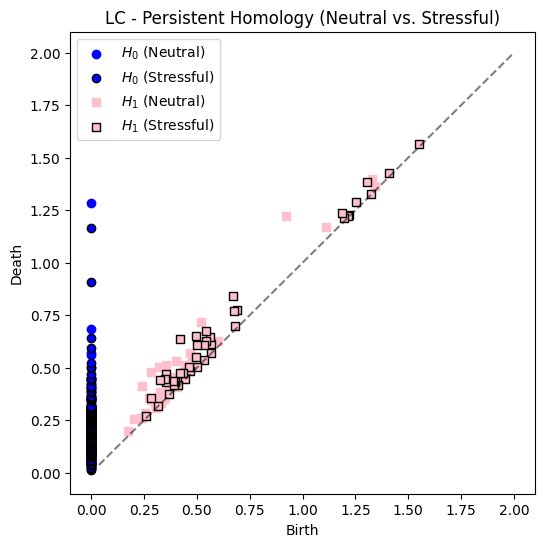

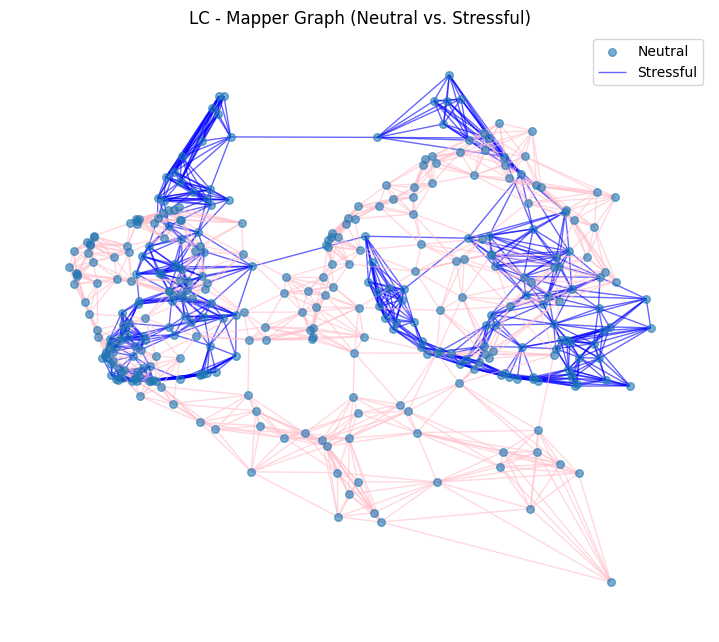

/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


Analyzing NE activations...


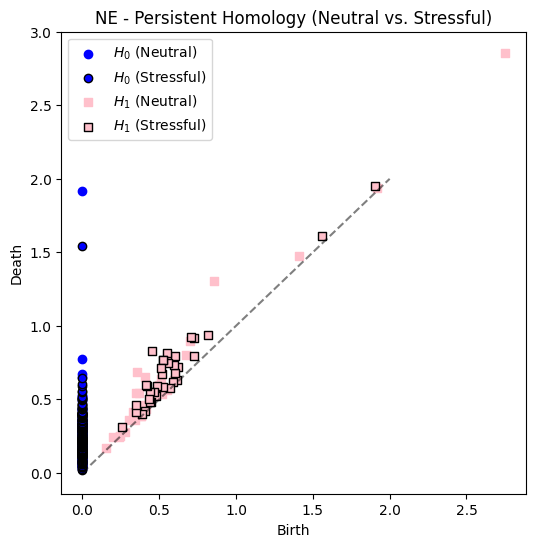

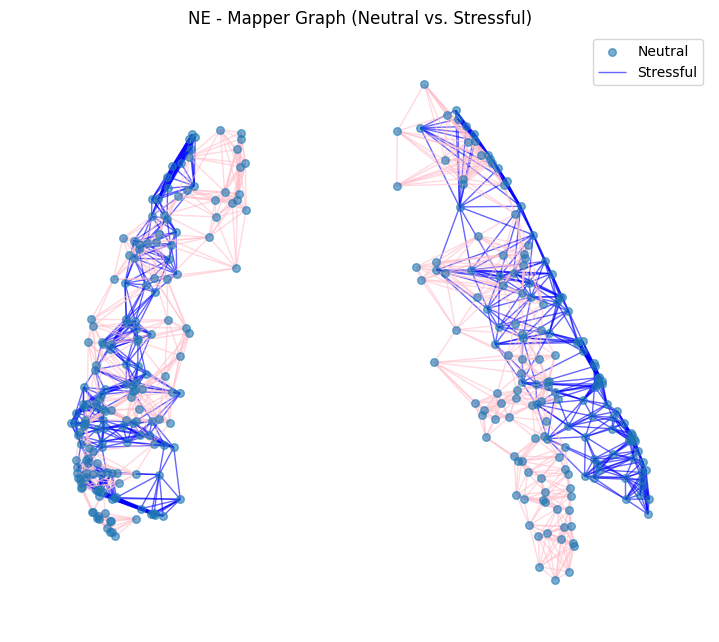

Analyzing Tonic_NE activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


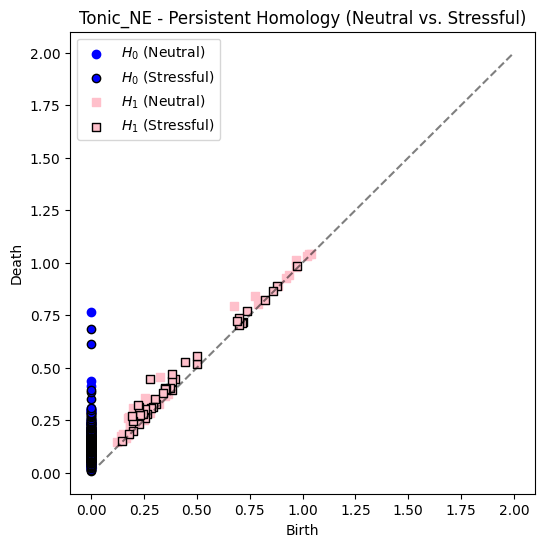

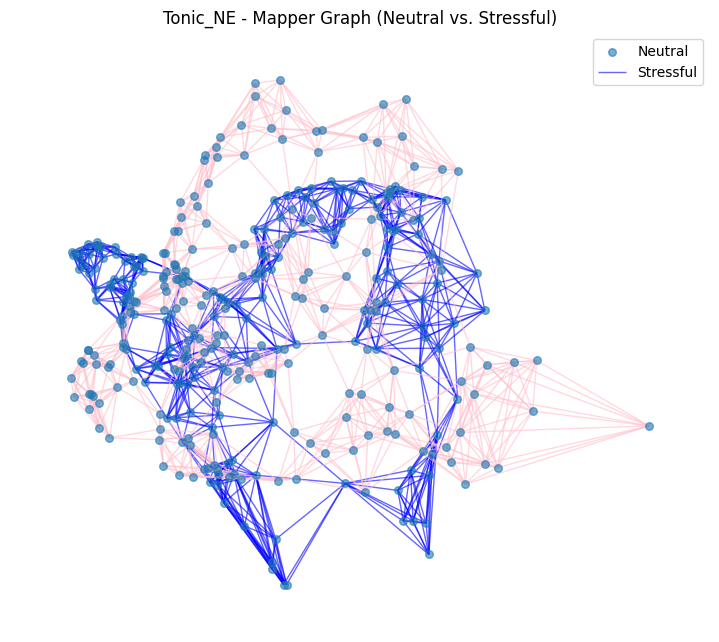

Analyzing Phasic_NE activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


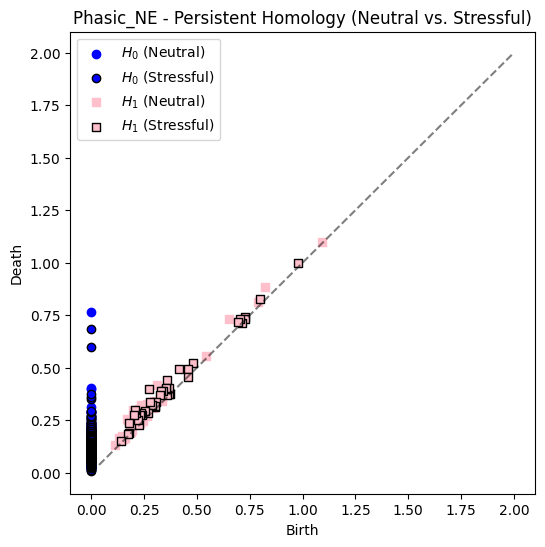

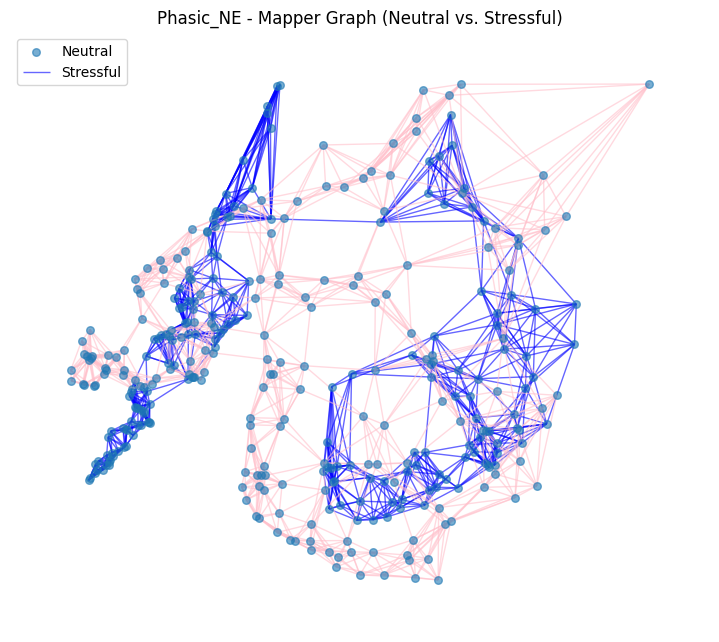

Analyzing Hidden_1 activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


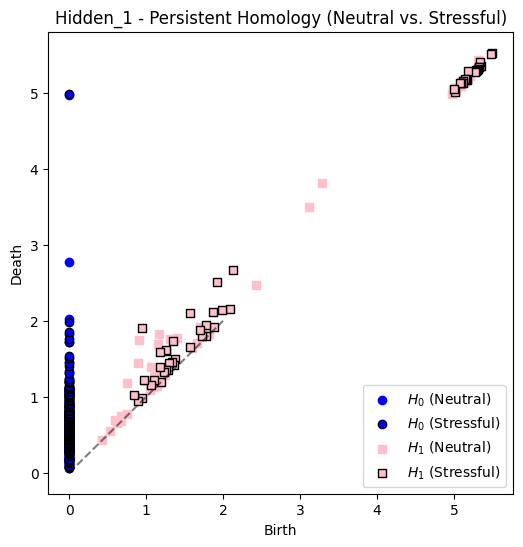

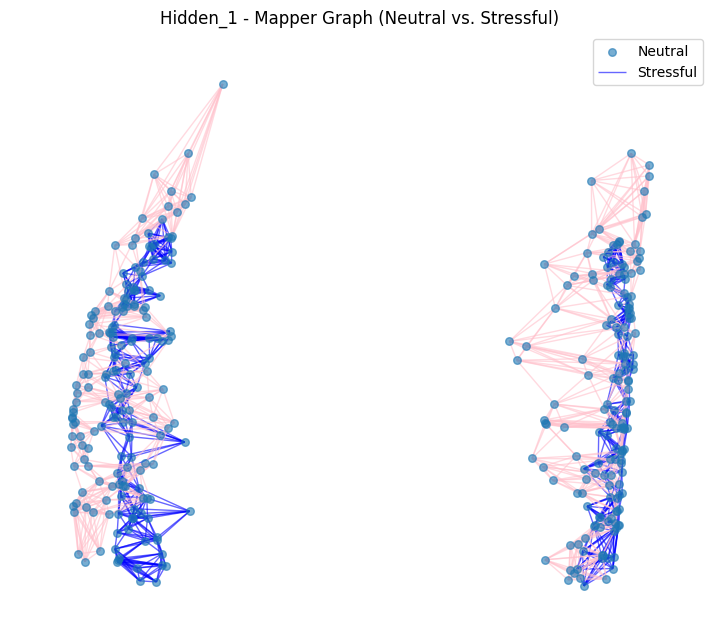

Analyzing Hidden_2 activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


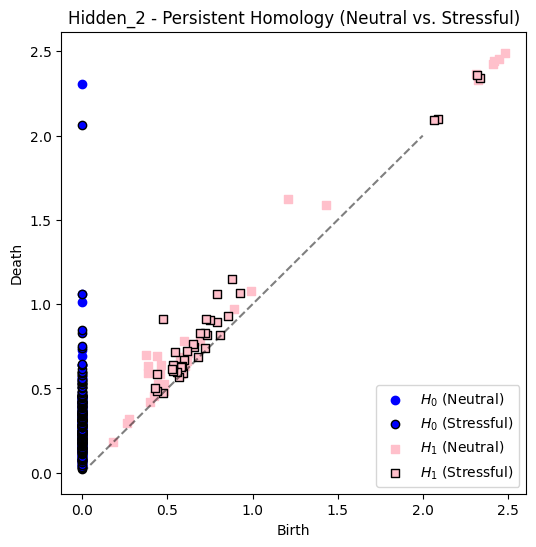

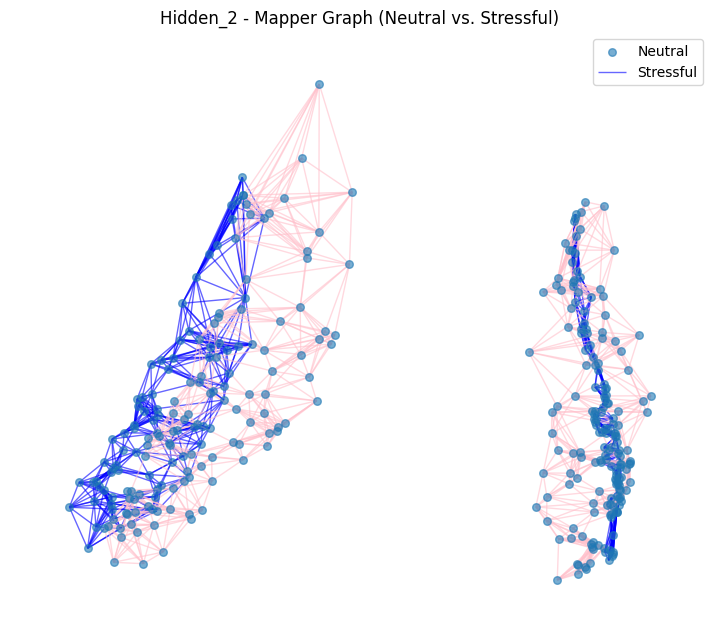

In [26]:
activations_neutral = extract_activations_gadget(ff_uncertain_gadget, X_neutral_test)
activations_stress = extract_activations_gadget(ff_uncertain_gadget, X_stress_test)

for key in activations_neutral.keys():
    print(f"Analyzing {key} activations...")

    act_neutral = activations_neutral[key]
    act_stress = activations_stress[key]

    compute_persistent_homology_overlay(act_neutral, act_stress, title=f"{key} - Persistent Homology (Neutral vs. Stressful)")

    compute_mapper_graph_overlay(act_neutral, act_stress, title=f"{key} - Mapper Graph (Neutral vs. Stressful)")

# Experiments

In [27]:
from analysis.analysis import (analyze_uncertainty_relationships,
                               simulate_lc_activation)

In [28]:
ff_uncertain_gadget

FFGadgetUncertainController(
  (fc1): Linear(in_features=7, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (lcne_gadget): LCNEGadgetCompositional(
    (W_LC1): Linear(in_features=256, out_features=256, bias=True)
    (W_LC2): Linear(in_features=256, out_features=256, bias=True)
    (tonic_control): Linear(in_features=256, out_features=256, bias=True)
    (phasic_control): Linear(in_features=256, out_features=256, bias=True)
    (adaptive_weight): Linear(in_features=256, out_features=256, bias=True)
    (uncertainty_gate): Linear(in_features=256, out_features=256, bias=True)
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (tanh): Tanh()
    (sigmoid): Sigmoid()
  )
  (modulation_fc): Linear(in_features=512, out_features=256, bias=True)
  (Pupil_mean): Linear(in_features=256, out_features=1, bias=True)
  (Pupil_var): Linear(in_features=256, out_features=1, bias=True)
)

Adjusting prev_LC size: torch.Size([170, 256]) -> torch.Size([1699, 256])


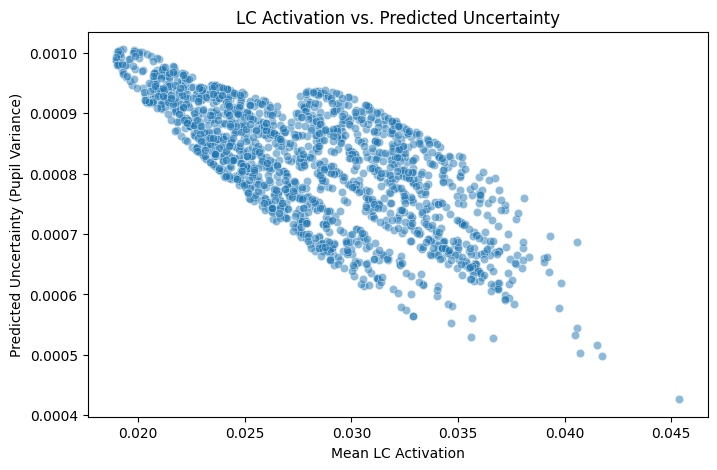

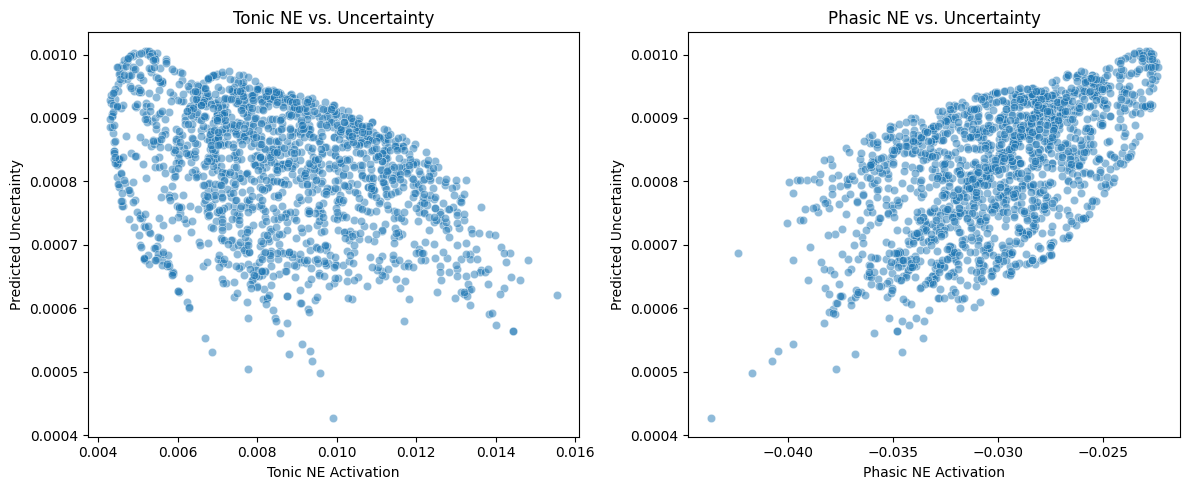


📊 **Correlation Results:**
LC vs. Uncertainty: -0.7280
Tonic NE vs. Uncertainty: -0.3551
Phasic NE vs. Uncertainty: 0.5729
NE vs. Uncertainty: -0.0539


In [29]:
uncertainty_results = analyze_uncertainty_relationships(ff_uncertain_gadget, X_tensor)

Adjusting prev_LC size: torch.Size([1699, 256]) -> torch.Size([340, 256])


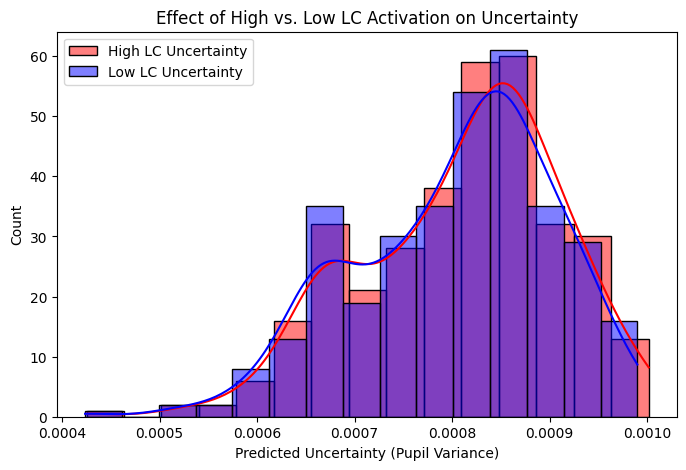

In [30]:
pupil_high, var_high, pupil_low, var_low = simulate_lc_activation(ff_uncertain_gadget, X_test, lc_boost=0.01)
plt.figure(figsize=(8,5))
sns.histplot(var_high.squeeze(), color="red", label="High LC Uncertainty", kde=True)
sns.histplot(var_low.squeeze(), color="blue", label="Low LC Uncertainty", kde=True)
plt.xlabel("Predicted Uncertainty (Pupil Variance)")
plt.title("Effect of High vs. Low LC Activation on Uncertainty")
plt.legend()
plt.show()

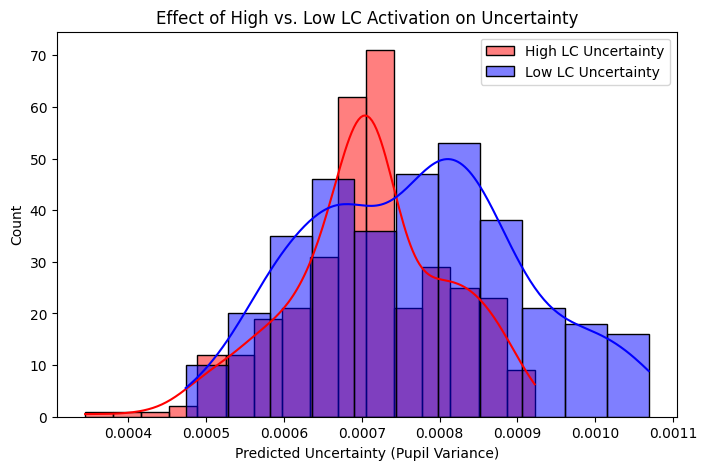

In [31]:
pupil_high, var_high, pupil_low, var_low = simulate_lc_activation(ff_uncertain_gadget, X_test, lc_boost=0.5)
plt.figure(figsize=(8,5))
sns.histplot(var_high.squeeze(), color="red", label="High LC Uncertainty", kde=True)
sns.histplot(var_low.squeeze(), color="blue", label="Low LC Uncertainty", kde=True)
plt.xlabel("Predicted Uncertainty (Pupil Variance)")
plt.title("Effect of High vs. Low LC Activation on Uncertainty")
plt.legend()
plt.show()